In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# EDA

In [5]:
df = pd.read_csv('insurance.csv')
df

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
0,1,39.0,male,23.2,91,Yes,0,No,southeast,1121.87
1,2,24.0,male,30.1,87,No,0,No,southeast,1131.51
2,3,NaN,male,33.3,82,Yes,0,No,southeast,1135.94
3,4,NaN,male,33.7,80,No,0,No,northwest,1136.40
4,5,NaN,male,34.1,100,No,0,No,northwest,1137.01
...,...,...,...,...,...,...,...,...,...,...
1335,1336,44.0,female,35.5,88,Yes,0,Yes,northwest,55135.40
1336,1337,59.0,female,38.1,120,No,1,Yes,northeast,58571.07
1337,1338,30.0,male,34.5,91,Yes,3,Yes,northwest,60021.40
1338,1339,37.0,male,30.4,106,No,0,Yes,southeast,62592.87


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1340 non-null   int64  
 1   age            1335 non-null   float64
 2   gender         1340 non-null   object 
 3   bmi            1340 non-null   float64
 4   bloodpressure  1340 non-null   int64  
 5   diabetic       1340 non-null   object 
 6   children       1340 non-null   int64  
 7   smoker         1340 non-null   object 
 8   region         1337 non-null   object 
 9   claim          1340 non-null   float64
dtypes: float64(3), int64(3), object(4)
memory usage: 104.8+ KB


In [7]:
df.shape

(1340, 10)

In [8]:
pd.set_option('display.float_format', "{:.2f}".format)
df

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
0,1,39.00,male,23.20,91,Yes,0,No,southeast,1121.87
1,2,24.00,male,30.10,87,No,0,No,southeast,1131.51
2,3,NaN,male,33.30,82,Yes,0,No,southeast,1135.94
3,4,NaN,male,33.70,80,No,0,No,northwest,1136.40
4,5,NaN,male,34.10,100,No,0,No,northwest,1137.01
...,...,...,...,...,...,...,...,...,...,...
1335,1336,44.00,female,35.50,88,Yes,0,Yes,northwest,55135.40
1336,1337,59.00,female,38.10,120,No,1,Yes,northeast,58571.07
1337,1338,30.00,male,34.50,91,Yes,3,Yes,northwest,60021.40
1338,1339,37.00,male,30.40,106,No,0,Yes,southeast,62592.87


In [9]:
sns.set(style="whitegrid", palette="Set2", font_scale=1.1)

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.isna().sum()

Id               0
age              5
gender           0
bmi              0
bloodpressure    0
diabetic         0
children         0
smoker           0
region           3
claim            0
dtype: int64

since the null values are relatively little and we wont loose too many information, we can just drop the values

In [12]:
df.dropna(inplace=True)

In [13]:
df.shape

(1332, 10)

In [14]:
df.isna().sum().sum()

np.int64(0)

In [15]:
df.describe(include='all')

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
count,1332.00,1332.00,1332,1332.00,1332.00,1332,1332.00,1332,1332,1332.00
unique,NaN,NaN,2,NaN,NaN,2,NaN,2,4,NaN
top,NaN,NaN,male,NaN,NaN,No,NaN,No,southeast,NaN
freq,NaN,NaN,670,NaN,NaN,695,NaN,1058,442,NaN
mean,674.47,38.09,NaN,30.66,94.19,NaN,1.10,NaN,NaN,13325.25
std,384.70,11.11,NaN,6.12,11.45,NaN,1.21,NaN,NaN,12109.62
min,1.00,18.00,NaN,16.00,80.00,NaN,0.00,NaN,NaN,1121.87
25%,341.75,29.00,NaN,26.20,86.00,NaN,0.00,NaN,NaN,4760.16
50%,674.50,38.00,NaN,30.35,92.00,NaN,1.00,NaN,NaN,9412.97
75%,1007.25,47.00,NaN,34.73,99.00,NaN,2.00,NaN,NaN,16781.33


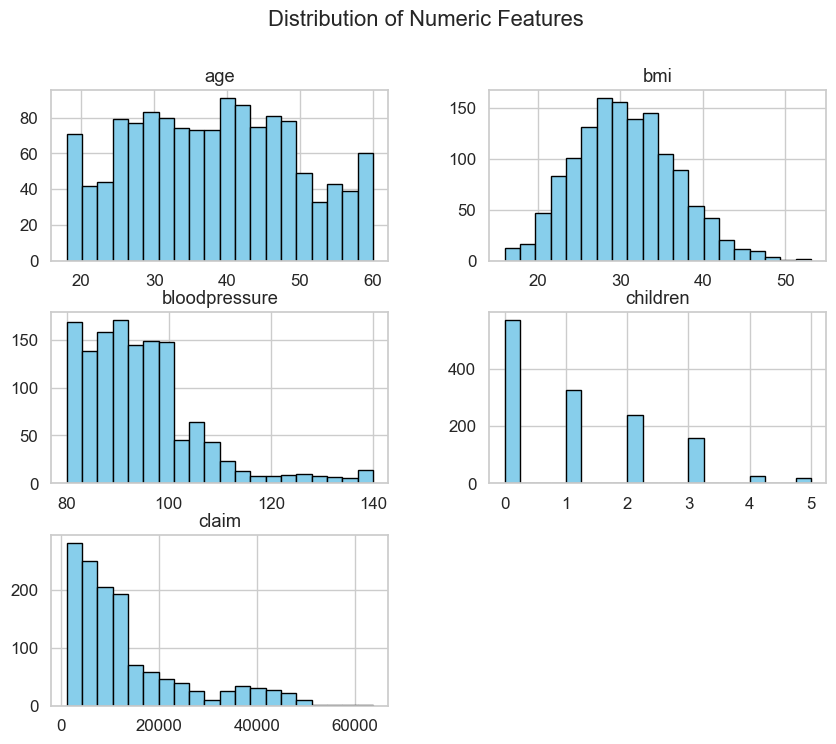

In [16]:
numeric_cols = ['age', 'bmi', 'bloodpressure','children', 'claim']
df[numeric_cols].hist(bins=20, figsize=(10, 8), color='skyblue', edgecolor='black')
plt.suptitle('Distribution of Numeric Features')
plt.show()

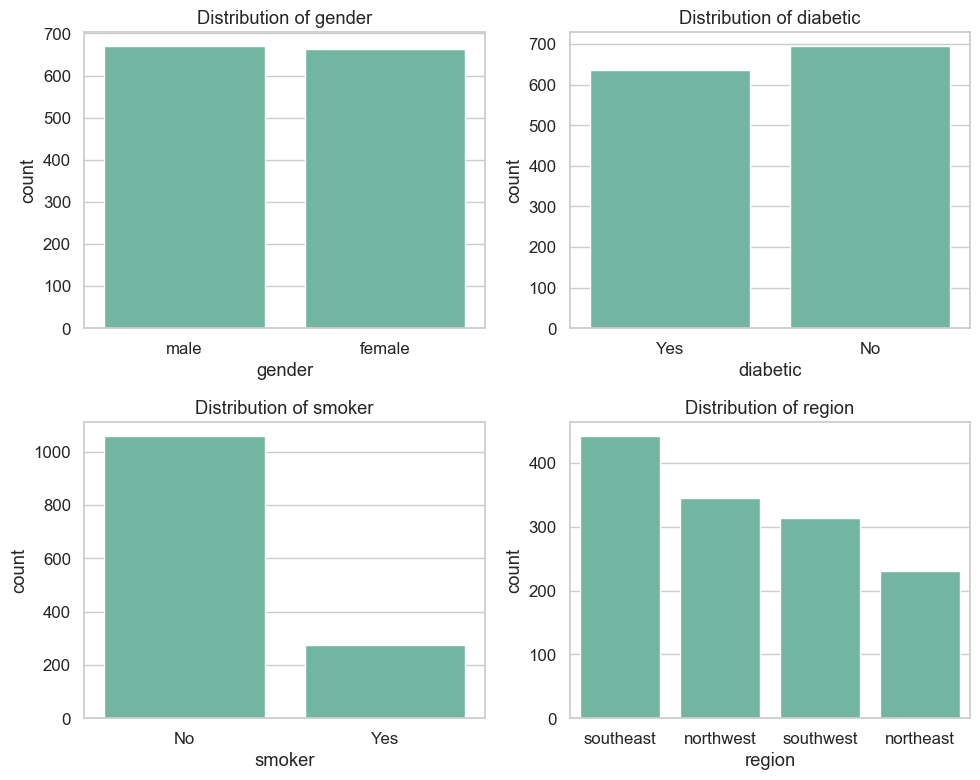

In [17]:
categorical_cols = ['gender', 'diabetic', 'smoker', 'region']
plt.figure(figsize=(10, 8))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(2, 2, i)
    sns.countplot(data=df, x=col)
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

#### Claims by gender/smoker/non smoker

In [18]:
df.groupby(['gender', 'smoker'])['claim'].mean().round(2)

gender  smoker
female  No        8762.30
        Yes      30679.00
male    No        8169.25
        Yes      33042.01
Name: claim, dtype: float64

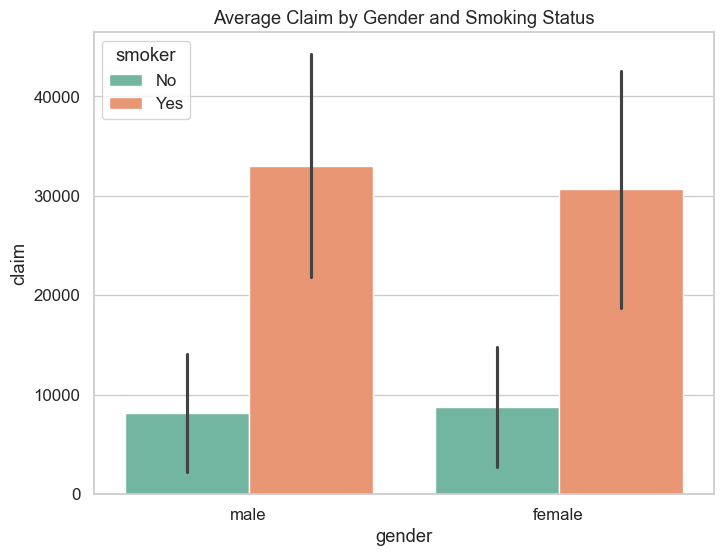

In [19]:
plt.figure(figsize=(8, 6))
sns.barplot(data=df, x='gender', y='claim', hue='smoker', estimator = 'mean', errorbar = 'sd')
plt.title('Average Claim by Gender and Smoking Status')
plt.show()

#### Claims by region and diabetic status

In [20]:
pivot_region_diabetic = df.groupby(['region', 'diabetic'])['claim'].mean().unstack()
pivot_region_diabetic

diabetic,No,Yes
region,,
northeast,16966.86,16818.30
northwest,11442.83,12224.96
southeast,13578.72,12574.09
southwest,13069.91,12313.74


Text(0, 0.5, 'Mean Claim')

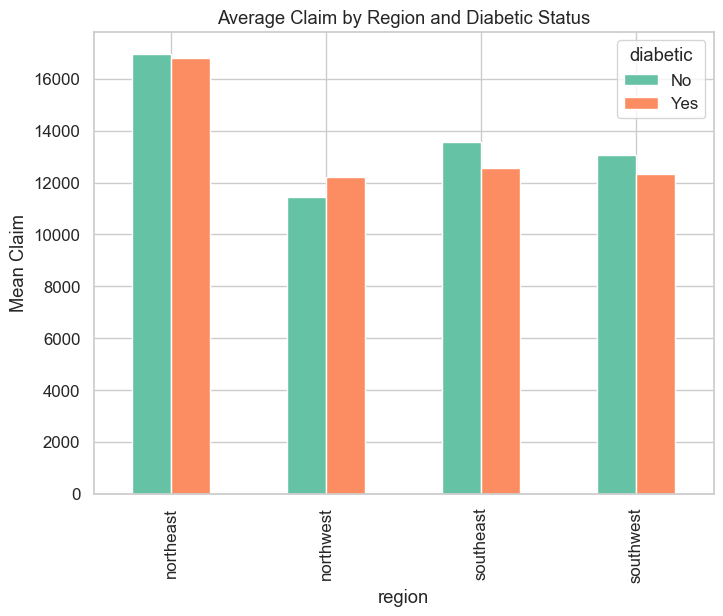

In [21]:
pivot_region_diabetic.plot(kind='bar', figsize=(8, 6))
plt.title('Average Claim by Region and Diabetic Status')
plt.ylabel('Mean Claim')

we can see that diabetic status doesn't really affect insurance claims and northeast has higher claims on average

#### Claims by smoker and region

In [22]:
pivot_smoker_region = pd.pivot_table(data=df, index='region', columns='smoker', values='claim', aggfunc='mean')
pivot_smoker_region

smoker,No,Yes
region,,
northeast,11666.11,29673.54
northwest,8076.20,30192.00
southeast,7444.14,34845.00
southwest,8294.75,32269.06


#### Claim by diabetic status and children count

In [23]:
pivot_children_diabetic = pd.pivot_table(data=df, index='children', columns='diabetic', values='claim', aggfunc='mean')
pivot_children_diabetic

diabetic,No,Yes
children,,
0,12967.40,11985.29
1,12730.46,12732.06
2,15567.77,14579.36
3,13807.61,17091.26
4,14106.63,13573.35
5,8519.04,9205.59


In [24]:
numeric_cols

['age', 'bmi', 'bloodpressure', 'children', 'claim']

In [25]:
df[numeric_cols].corr()

,age,bmi,bloodpressure,children,claim
age,1.00,-0.04,-0.06,-0.03,-0.03
bmi,-0.04,1.00,0.14,0.01,0.20
bloodpressure,-0.06,0.14,1.00,-0.03,0.53
children,-0.03,0.01,-0.03,1.00,0.06
claim,-0.03,0.20,0.53,0.06,1.00


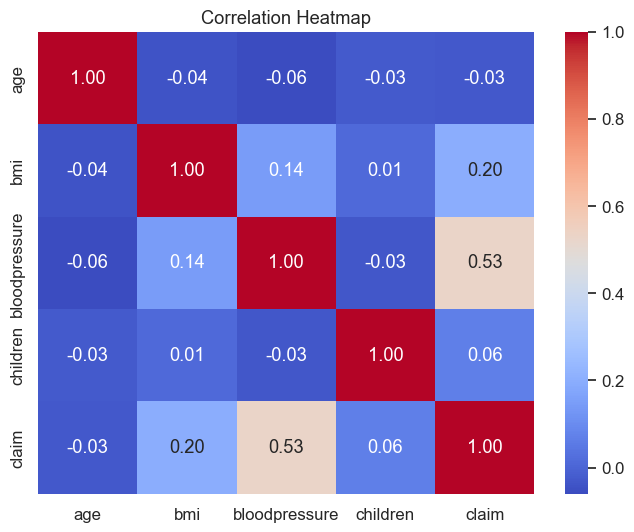

In [26]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

from the heatmap, we can see that among the numeric columns, only bloodpressure is a little more correlated with claim

## Relationship analysis

#### Claim vs Age

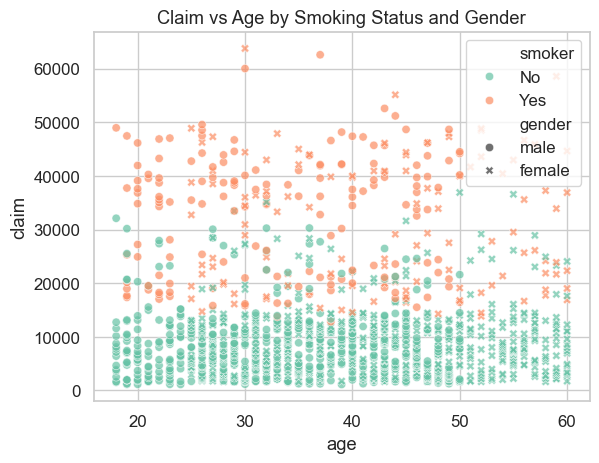

In [27]:
sns.scatterplot(data=df, x='age', y='claim', hue='smoker', style = 'gender', alpha=0.7)
plt.title('Claim vs Age by Smoking Status and Gender')
plt.show()

generally higher claims by smokers

#### Claim vs BMI

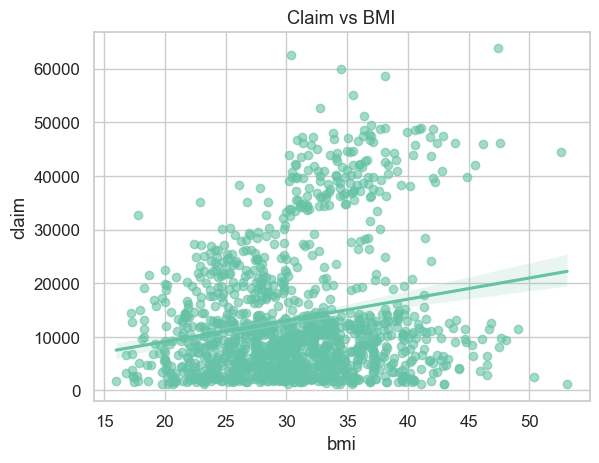

In [28]:
sns.regplot(data=df, x='bmi', y='claim', scatter_kws={'alpha':0.6})
plt.title('Claim vs BMI')   
plt.show()

general trend: higher bmi, higher claim

#### Claim vs Children

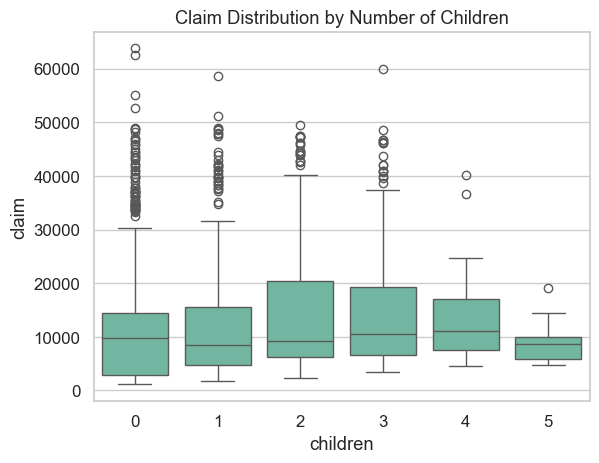

In [29]:
sns.boxplot(data=df, x='children', y='claim')
plt.title('Claim Distribution by Number of Children')
plt.show()

#### Claim vs Age

In [30]:
df['age_group'] = pd.cut(df['age'], bins=[0, 18, 30, 45, 60, 100], labels=['<18', '18-30', '31-45', '46-60', '60+'])

In [31]:
df

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim,age_group
0,1,39.00,male,23.20,91,Yes,0,No,southeast,1121.87,31-45
1,2,24.00,male,30.10,87,No,0,No,southeast,1131.51,18-30
7,8,19.00,male,41.10,100,No,0,No,northwest,1146.80,18-30
8,9,20.00,male,43.00,86,No,0,No,northwest,1149.40,18-30
9,10,30.00,male,53.10,97,No,0,No,northwest,1163.46,18-30
...,...,...,...,...,...,...,...,...,...,...,...
1335,1336,44.00,female,35.50,88,Yes,0,Yes,northwest,55135.40,31-45
1336,1337,59.00,female,38.10,120,No,1,Yes,northeast,58571.07,46-60
1337,1338,30.00,male,34.50,91,Yes,3,Yes,northwest,60021.40,18-30
1338,1339,37.00,male,30.40,106,No,0,Yes,southeast,62592.87,31-45


In [32]:
df['age_group'].value_counts()

age_group
31-45    553
46-60    383
18-30    380
<18       16
60+        0
Name: count, dtype: int64

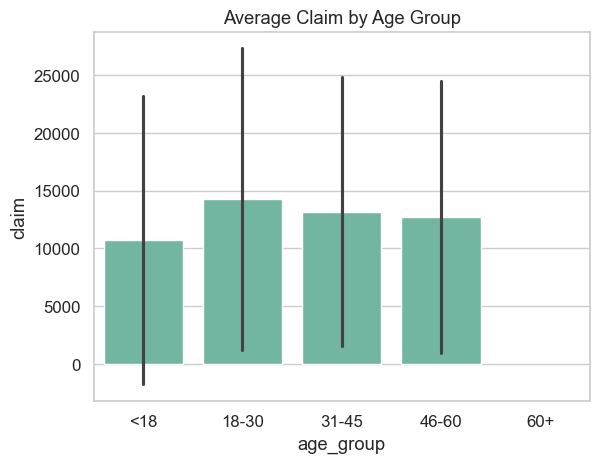

In [33]:
sns.barplot(data=df, x='age_group', y='claim', estimator='mean', errorbar='sd')
plt.title('Average Claim by Age Group')
plt.show()

#### Claim vs BMI

In [34]:
df['bmi_category'] = pd.cut(df['bmi'], bins=[0, 18.5, 24.9, 29.9, 100], labels=['Underweight', 'Normal', 'Overweight', 'Obese'])

In [35]:
df['bmi_category'].value_counts()

bmi_category
Obese          702
Overweight     387
Normal         222
Underweight     21
Name: count, dtype: int64

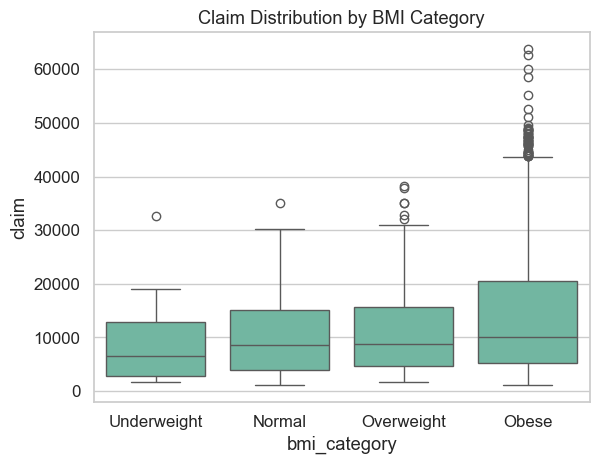

In [36]:
sns.boxplot(data=df, x='bmi_category', y='claim')
plt.title('Claim Distribution by BMI Category')
plt.show()

obese clients have highest claim amount

#### Smoker rate vs claim by region

In [37]:
region_stats = df.groupby('region').agg(
    smoker_rate =('smoker', lambda x: (x == 'Yes').mean() * 100),
    mean_claim = ('claim', 'mean')).reset_index()
region_stats

,region,smoker_rate,mean_claim
0,northeast,29.00,16889.04
1,northwest,16.81,11794.22
2,southeast,20.59,13085.50
3,southwest,18.47,12723.13


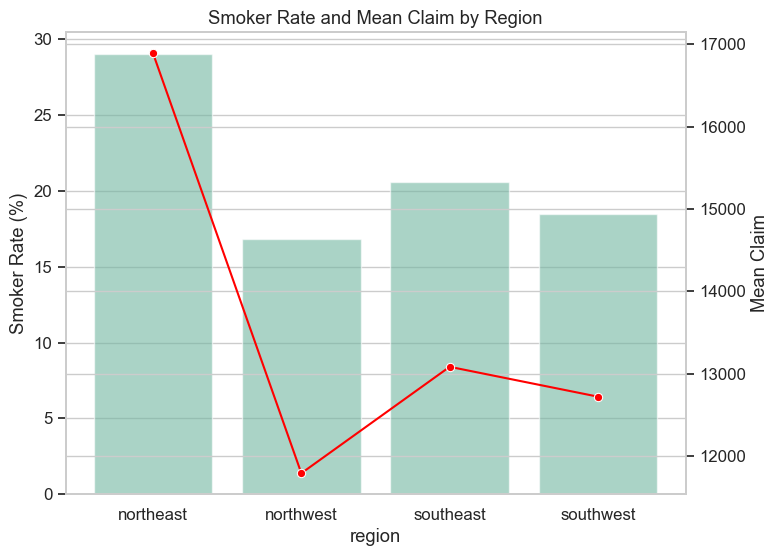

In [38]:
fig, ax1 = plt.subplots(figsize=(8, 6))
sns.barplot(data=region_stats, x='region', y='smoker_rate', ax=ax1, alpha=0.6)
ax2 = ax1.twinx()
sns.lineplot(data=region_stats, x='region', y='mean_claim', ax=ax2, color='red', marker='o')

ax1.set_ylabel('Smoker Rate (%)')
ax2.set_ylabel('Mean Claim')
plt.title('Smoker Rate and Mean Claim by Region')
plt.show()


# Feature Engineering

In [39]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import joblib

In [40]:
df.columns

Index(['Id', 'age', 'gender', 'bmi', 'bloodpressure', 'diabetic', 'children',
       'smoker', 'region', 'claim', 'age_group', 'bmi_category'],
      dtype='object')

In [41]:
X = df[['age', 'gender','bmi', 'bloodpressure', 'diabetic', 'children', 'smoker']]
y = df['claim']

In [42]:
X

,age,gender,bmi,bloodpressure,diabetic,children,smoker
0,39.00,male,23.20,91,Yes,0,No
1,24.00,male,30.10,87,No,0,No
7,19.00,male,41.10,100,No,0,No
8,20.00,male,43.00,86,No,0,No
9,30.00,male,53.10,97,No,0,No
...,...,...,...,...,...,...,...
1335,44.00,female,35.50,88,Yes,0,Yes
1336,59.00,female,38.10,120,No,1,Yes
1337,30.00,male,34.50,91,Yes,3,Yes
1338,37.00,male,30.40,106,No,0,Yes


In [43]:
cat_cols =  ['gender', 'diabetic', 'smoker']
label_encoders = {}

for col in cat_cols:
    le = LabelEncoder() #create a label encoder for the column
    X[col] = le.fit_transform(X[col]) #fit the label encoder to the column
    label_encoders[col] = le #store the label encoder in a dictionary for later use in prediction

    joblib.dump(le, f'label_encoder_{col}.pkl')  #save the label encoder for later use in prediction

C:\Users\User\AppData\Local\Temp\ipykernel_24292\1015623893.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = le.fit_transform(X[col]) #fit the label encoder to the column
C:\Users\User\AppData\Local\Temp\ipykernel_24292\1015623893.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = le.fit_transform(X[col]) #fit the label encoder to the column
C:\Users\User\AppData\Local\Temp\ipykernel_24292\1015623893.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a

In [44]:
X

,age,gender,bmi,bloodpressure,diabetic,children,smoker
0,39.00,1,23.20,91,1,0,0
1,24.00,1,30.10,87,0,0,0
7,19.00,1,41.10,100,0,0,0
8,20.00,1,43.00,86,0,0,0
9,30.00,1,53.10,97,0,0,0
...,...,...,...,...,...,...,...
1335,44.00,0,35.50,88,1,0,1
1336,59.00,0,38.10,120,0,1,1
1337,30.00,1,34.50,91,1,3,1
1338,37.00,1,30.40,106,0,0,1


the string colums are now encoded (diabetic, childeren and smoker)

In [45]:
label_encoders

{'gender': LabelEncoder(),
 'diabetic': LabelEncoder(),
 'smoker': LabelEncoder()}

### Split data into train and test

In [46]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [ ]:
# normalize the numeric features using StandardScaler
num_cols = ['age', 'bmi', 'bloodpressure','children']
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [48]:
joblib.dump(scaler, 'scaler.pkl') 

['scaler.pkl']

In [49]:
print(X_train.shape, y_train.shape)

(1065, 7) (1065,)


In [50]:
print(X_test.shape, y_test.shape)

(267, 7) (267,)


# Model Training

In [51]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor

### Evaluation function

In [52]:
def evaluate_model(model, X_train, X_test, y_train, y_test):
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mae = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mae)
    return { 'R2': r2, 'MAE': mae, 'RMSE': rmse }

In [53]:
results = {}

### Linear Regression

In [54]:
lr = LinearRegression()
lr.fit(X_train, y_train)
results['Linear Regression'] = evaluate_model(lr, X_train, X_test, y_train, y_test)
print('Linear Regression model trained')

Linear Regression model trained


### Polynomial Regression

In [55]:
best_poly_model = None
best_poly_score = -np.inf

for degree in [2,3]:
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    
    poly_lr = LinearRegression()
    poly_lr.fit(X_train_poly, y_train)
    
    score = poly_lr.score(X_test_poly, y_test)
    
    if score > best_poly_score:
        best_poly_score = score
        best_poly_model = (degree, poly, poly_lr)

degree, poly, poly_lr = best_poly_model
results[f'Polynomial Regression (deg = {degree})'] = evaluate_model(poly_lr, poly.fit_transform(X_train), poly.transform(X_test), y_train, y_test)
print('Polynomial Regression models are trained')

Polynomial Regression models are trained


### Random Forest

In [56]:
rf = RandomForestRegressor()

rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_grid = GridSearchCV(rf, rf_params, cv=3, scoring = 'r2', n_jobs=-1, verbose=0)
rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_
results['Random Forest'] = evaluate_model(best_rf, X_train, X_test, y_train, y_test)
print('Random Forest model trained, best params:', rf_grid.best_params_)

Random Forest model trained, best params: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}


### Support Vector Regression

In [57]:
svm = SVR()

svr_params = {
    'kernel': ['rbf', 'poly','linear'],
    'C': [1, 10, 50],
    'epsilon': [0.1, 0.2],
    'degree': [2, 3]  
}

svr_grid = GridSearchCV(svm, svr_params, cv=3, scoring='r2', n_jobs=-1, verbose=0)
svr_grid.fit(X_train, y_train)

best_svr = svr_grid.best_estimator_
results['SVR'] = evaluate_model(best_svr, X_train, X_test, y_train, y_test)
print('SVR model trained, best params:', svr_grid.best_params_)

SVR model trained, best params: {'C': 50, 'degree': 2, 'epsilon': 0.2, 'kernel': 'linear'}


### XG Boost

In [58]:
xgb = XGBRegressor(objective='reg:squarederror')

xgb_params = {
    'n_estimators': [100, 200], 
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1],
}

xgb_grid = GridSearchCV(xgb, xgb_params, cv=3, scoring='r2', n_jobs=-1, verbose=0)
xgb_grid.fit(X_train, y_train)

best_xgb = xgb_grid.best_estimator_
results['XGBoost'] = evaluate_model(best_xgb, X_train, X_test, y_train, y_test)
print('XGBoost model trained, best params:', xgb_grid.best_params_)

XGBoost model trained, best params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}


In [60]:
results

{'Linear Regression': {'R2': 0.6874341877629946,
  'MAE': 51112612.67047968,
  'RMSE': np.float64(7149.3085449209475)},
 'Polynomial Regression (deg = 2)': {'R2': 0.7504121737602346,
  'MAE': 40814079.4367714,
  'RMSE': np.float64(6388.589784668554)},
 'Random Forest': {'R2': 0.7884542223450157,
  'MAE': 34593218.36246072,
  'RMSE': np.float64(5881.599983207011)},
 'SVR': {'R2': 0.4625708566327543,
  'MAE': 87883596.24541673,
  'RMSE': np.float64(9374.625125593915)},
 'XGBoost': {'R2': 0.7950542884310091,
  'MAE': 33513936.4696696,
  'RMSE': np.float64(5789.122253819623)}}

In [59]:
results_df = pd.DataFrame(results).T.sort_values(by='R2', ascending=False)
results_df

,R2,MAE,RMSE
XGBoost,0.80,33513936.47,5789.12
Random Forest,0.79,34593218.36,5881.60
Polynomial Regression (deg = 2),0.75,40814079.44,6388.59
Linear Regression,0.69,51112612.67,7149.31
SVR,0.46,87883596.25,9374.63


In [61]:
models = {
    'Linear Regression': lr,
    'Polynomial Regression': poly_lr,
    'Random Forest': best_rf,
    'SVR': best_svr,
    'XGBoost': best_xgb
}

In [68]:
best_r2 = results_df['R2'].max()
best_r2

np.float64(0.7950542884310091)

In [67]:
top_model = results_df[results_df['R2'] == best_r2]
top_model

,R2,MAE,RMSE
XGBoost,0.80,33513936.47,5789.12


In [69]:
best_model = models[top_model.index[0]]
best_model

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [71]:
joblib.dump(best_model, 'best_model.pkl')
print(f'Best model: {top_model.index[0]} saved as best_model.pkl')

Best model: XGBoost saved as best_model.pkl
